# Dengue Data Build — Singapore Weekly Cases + Weather

This notebook builds the base weekly dataset for the dengue outbreak prediction project.

## Goals
- Load raw Singapore dengue surveillance data
- Load raw historical weather data
- Clean and align both sources to weekly resolution
- Merge them into one modeling-ready weekly table
- Save interim and processed outputs for downstream notebooks

## Inputs
### Disease data
- Source: data.gov.sg / MOH weekly dengue dataset
- Region: Singapore

### Weather data
- Source: Open-Meteo historical weather archive
- Variables:
  - `temperature_2m_max`
  - `temperature_2m_min`
  - `precipitation_sum`
  - `wind_speed_10m_max`
  - `shortwave_radiation_sum`

## Outputs
### Interim
- `dengue_weekly_disease.parquet`
- `dengue_daily_weather.parquet`
- `dengue_weekly_weather.parquet`

### Processed
- `dengue_weekly_merged.parquet`
- `dengue_weekly_merged.csv`

## Notes
- This notebook is for data build only
- Outbreak labeling, lag features, and modeling will be handled later in `11_dengue_model.ipynb`

In [2]:
from pathlib import Path
import sys
import json

import pandas as pd
import matplotlib.pyplot as plt

sys.path.append(str(Path("..").resolve()))

from config import savefig, save_parquet, save_csv, print_config_summary

print_config_summary()

===== CONFIG SUMMARY =====
Base Dir: /Users/suvo/Projects/disease-outbreak
Default Disease: flu
Default Region: illinois
Forecast Horizons: [1, 2, 3, 4]
Default Lags: [1, 2, 3, 4]
Default Outbreak Quantile: 0.85
Raw Data Dir: /Users/suvo/Projects/disease-outbreak/data/raw
Interim Data Dir: /Users/suvo/Projects/disease-outbreak/data/interim
Processed Data Dir: /Users/suvo/Projects/disease-outbreak/data/processed
Figures Dir: /Users/suvo/Projects/disease-outbreak/outputs/figures
Tables Dir: /Users/suvo/Projects/disease-outbreak/outputs/tables
Models Dir: /Users/suvo/Projects/disease-outbreak/outputs/models
Flu Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/fluview_il_201040_202652.json
Flu Weather Raw JSON: /Users/suvo/Projects/disease-outbreak/data/raw/flu/weather_openmeteo_springfield_il_2010-10-01_2026-04-10.json


In [3]:
RAW_DIR = Path("../data/raw/dengue")

dengue_path = RAW_DIR / "dengue_singapore_weekly_2014_2018.json"
weather_path = RAW_DIR / "weather_openmeteo_singapore_2014-01-01_2018-12-31.json"

print(dengue_path)
print(weather_path)
print(dengue_path.exists(), weather_path.exists())

../data/raw/dengue/dengue_singapore_weekly_2014_2018.json
../data/raw/dengue/weather_openmeteo_singapore_2014-01-01_2018-12-31.json
True True


In [4]:
with open(dengue_path, "r") as f:
    dengue_json = json.load(f)

with open(weather_path, "r") as f:
    weather_json = json.load(f)

print("DENGUE TOP-LEVEL KEYS:")
print(dengue_json.keys())

print("\nWEATHER TOP-LEVEL KEYS:")
print(weather_json.keys())

DENGUE TOP-LEVEL KEYS:
dict_keys(['success', 'result'])

WEATHER TOP-LEVEL KEYS:
dict_keys(['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'daily_units', 'daily'])


In [5]:
print("DENGUE JSON SAMPLE:")
for k, v in dengue_json.items():
    if isinstance(v, list):
        print(k, f"list length = {len(v)}")
    elif isinstance(v, dict):
        print(k, f"dict keys = {list(v.keys())[:10]}")
    else:
        print(k, v)

DENGUE JSON SAMPLE:
success True
result dict keys = ['resource_id', 'fields', 'records', '_links', 'total', 'limit']


In [6]:
# likely structure: result -> records
result = dengue_json.get("result", {})
print(type(result))
print(result.keys() if isinstance(result, dict) else result)

<class 'dict'>
dict_keys(['resource_id', 'fields', 'records', '_links', 'total', 'limit'])


In [7]:
dengue_df = pd.DataFrame(result["records"]).copy()
dengue_df.head()

,_id,year,eweek,type_dengue,number
0,1,2014,1,Dengue,436
1,2,2014,1,DHF,1
2,3,2014,2,Dengue,479
3,4,2014,2,DHF,0
4,5,2014,3,Dengue,401


In [8]:
dengue_df.columns.tolist(), dengue_df.shape

(['_id', 'year', 'eweek', 'type_dengue', 'number'], (530, 5))

In [9]:
daily_weather = pd.DataFrame(weather_json["daily"]).copy()
daily_weather.head()

,time,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2014-01-01,27.5,24.2,2.1,16.3,14.65
1,2014-01-02,27.9,24.2,0.9,16.6,17.65
2,2014-01-03,27.7,24.4,2.3,15.0,15.70
3,2014-01-04,28.2,24.1,1.1,13.0,16.42
4,2014-01-05,26.3,23.7,9.1,15.3,10.00


In [10]:
for col in dengue_df.columns:
    print(col, dengue_df[col].dropna().unique()[:10])

_id [ 1  2  3  4  5  6  7  8  9 10]
year <ArrowStringArray>
['2014', '2015', '2016', '2017', '2018']
Length: 5, dtype: str
eweek <ArrowStringArray>
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
Length: 10, dtype: str
type_dengue <ArrowStringArray>
['Dengue', 'DHF']
Length: 2, dtype: str
number <ArrowStringArray>
['436', '1', '479', '0', '401', '336', '234', '273', '369', '193']
Length: 10, dtype: str


In [12]:
# Keep only actual dengue (not DHF)
dengue_df = dengue_df[dengue_df["type_dengue"] == "Dengue"].copy()

# Clean obvious whitespace
for col in ["year", "eweek", "number", "type_dengue"]:
    dengue_df[col] = dengue_df[col].astype(str).str.strip()

# Convert numeric columns safely
for col in ["year", "eweek", "number"]:
    dengue_df[col] = pd.to_numeric(dengue_df[col], errors="coerce")

# Inspect rows that failed conversion
bad_rows = dengue_df[dengue_df[["year", "eweek", "number"]].isna().any(axis=1)].copy()
print("Rows with NA/non-numeric values:")
display(bad_rows)

# Drop bad rows for now
dengue_df = dengue_df.dropna(subset=["year", "eweek", "number"]).copy()

# Convert to int after cleaning
dengue_df["year"] = dengue_df["year"].astype(int)
dengue_df["eweek"] = dengue_df["eweek"].astype(int)
dengue_df["number"] = dengue_df["number"].astype(int)

print(dengue_df.shape)
display(dengue_df.head())

Rows with NA/non-numeric values:


,_id,year,eweek,type_dengue,number
210,211,2015,53,Dengue,NaN
316,317,2016,53,Dengue,NaN
422,423,2017,53,Dengue,NaN
528,529,2018,53,Dengue,NaN


(261, 5)


,_id,year,eweek,type_dengue,number
0,1,2014,1,Dengue,436
2,3,2014,2,Dengue,479
4,5,2014,3,Dengue,401
6,7,2014,4,Dengue,336
8,9,2014,5,Dengue,234


In [13]:
dengue_df["epiweek"] = dengue_df["year"] * 100 + dengue_df["eweek"]

dengue_df.head()

,_id,year,eweek,type_dengue,number,epiweek
0,1,2014,1,Dengue,436,201401
2,3,2014,2,Dengue,479,201402
4,5,2014,3,Dengue,401,201403
6,7,2014,4,Dengue,336,201404
8,9,2014,5,Dengue,234,201405


In [14]:
from datetime import datetime, timedelta

def epiweek_to_date(epiweek):
    year = int(str(epiweek)[:4])
    week = int(str(epiweek)[4:])
    
    jan1 = datetime(year, 1, 1)
    first_sunday = jan1 + timedelta(days=(6 - jan1.weekday()) % 7)
    
    return first_sunday + timedelta(weeks=week - 1)

dengue_df["week_start"] = dengue_df["epiweek"].apply(epiweek_to_date)

dengue_df[["year", "eweek", "week_start"]].head(10)

,year,eweek,week_start
0,2014,1,2014-01-05
2,2014,2,2014-01-12
4,2014,3,2014-01-19
6,2014,4,2014-01-26
8,2014,5,2014-02-02
10,2014,6,2014-02-09
12,2014,7,2014-02-16
14,2014,8,2014-02-23
16,2014,9,2014-03-02
18,2014,10,2014-03-09


In [15]:
dengue_df = dengue_df[["week_start", "number"]].copy()

dengue_df = dengue_df.sort_values("week_start").reset_index(drop=True)

print(dengue_df.shape)
dengue_df.head()

(261, 2)


,week_start,number
0,2014-01-05,436
1,2014-01-12,479
2,2014-01-19,401
3,2014-01-26,336
4,2014-02-02,234


In [16]:
daily_weather["time"] = pd.to_datetime(daily_weather["time"])
daily_weather = daily_weather.sort_values("time")
daily_weather = daily_weather.set_index("time")

In [17]:
weekly_weather = (
    daily_weather
    .resample("W-SUN")
    .agg({
        "temperature_2m_max": "mean",
        "temperature_2m_min": "mean",
        "precipitation_sum": "sum",
        "wind_speed_10m_max": "mean",
        "shortwave_radiation_sum": "mean",
    })
    .reset_index()
    .rename(columns={"time": "week_start"})
)

print(weekly_weather.shape)
weekly_weather.head()

(262, 6)


,week_start,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2014-01-05,27.520000,24.120000,15.5,15.240000,14.884000
1,2014-01-12,27.871429,23.828571,40.8,13.442857,17.071429
2,2014-01-19,27.300000,23.885714,5.9,20.642857,17.952857
3,2014-01-26,27.142857,23.214286,1.5,19.128571,19.302857
4,2014-02-02,28.271429,22.828571,0.7,19.042857,22.348571


In [18]:
merged_df = pd.merge(
    dengue_df,
    weekly_weather,
    on="week_start",
    how="inner"
)

print(merged_df.shape)
merged_df.head()

(261, 7)


,week_start,number,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,shortwave_radiation_sum
0,2014-01-05,436,27.520000,24.120000,15.5,15.240000,14.884000
1,2014-01-12,479,27.871429,23.828571,40.8,13.442857,17.071429
2,2014-01-19,401,27.300000,23.885714,5.9,20.642857,17.952857
3,2014-01-26,336,27.142857,23.214286,1.5,19.128571,19.302857
4,2014-02-02,234,28.271429,22.828571,0.7,19.042857,22.348571


Saved figure: /Users/suvo/Projects/disease-outbreak/outputs/figures/dengue/dengue_cases_over_time.png


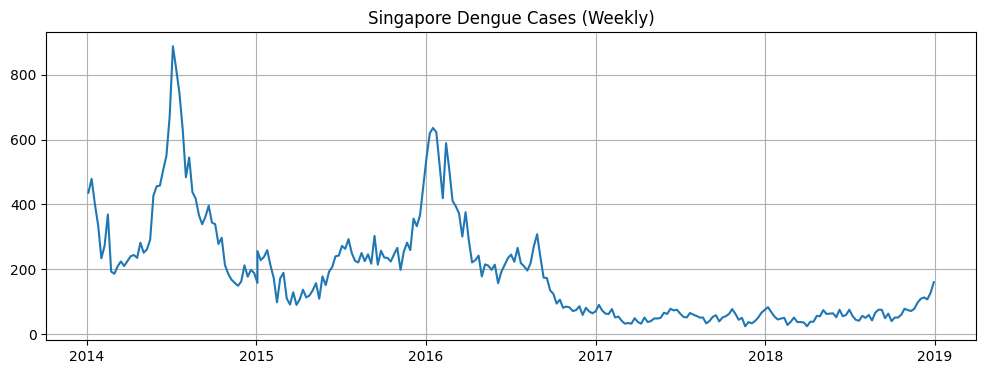

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(merged_df["week_start"], merged_df["number"])
ax.set_title("Singapore Dengue Cases (Weekly)")
ax.grid(True)

savefig(fig, "dengue_cases_over_time.png", subdir="dengue")
plt.show()

In [22]:
from pathlib import Path

save_parquet(dengue_df, Path("../data/interim/dengue/dengue_weekly_disease.parquet"))
save_parquet(daily_weather.reset_index(), Path("../data/interim/dengue/dengue_daily_weather.parquet"))
save_parquet(weekly_weather, Path("../data/interim/dengue/dengue_weekly_weather.parquet"))

save_parquet(merged_df, Path("../data/processed/dengue/dengue_weekly_merged.parquet"))
save_csv(merged_df, Path("../data/processed/dengue/dengue_weekly_merged.csv"))

Saved parquet: ../data/interim/dengue/dengue_weekly_disease.parquet
Saved parquet: ../data/interim/dengue/dengue_daily_weather.parquet
Saved parquet: ../data/interim/dengue/dengue_weekly_weather.parquet
Saved parquet: ../data/processed/dengue/dengue_weekly_merged.parquet
Saved csv: ../data/processed/dengue/dengue_weekly_merged.csv


PosixPath('../data/processed/dengue/dengue_weekly_merged.csv')